In [1]:
#1:importing libs
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# -------------------------------
# 2:Loading the Dataset
# -------------------------------
housing = fetch_california_housing()

# Create DataFrame
df = pd.DataFrame(housing.data, columns=housing.feature_names)

# Add Target Column
df['Price'] = housing.target

# -------------------------------
# Step 3: Display Dataset
# -------------------------------
print("First 5 Rows of California Housing Dataset:\n")
df.head()

First 5 Rows of California Housing Dataset:



,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [2]:
# -------------------------------
# Step 4: Define Features and Target
# -------------------------------
X = df.drop('Price', axis=1)   # Independent Variables
y = df['Price']                # Dependent Variable

# -------------------------------
# Step 5: Split Dataset
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (16512, 8)
Testing Data Shape: (4128, 8)


In [4]:
# -------------------------------
# Step 6: Create Linear Regression Model
# -------------------------------
model = LinearRegression()

# -------------------------------
# Step 7: Train the Model
# -------------------------------
model.fit(X_train, y_train)

print("Model Training Completed")

Model Training Completed


In [5]:
# -------------------------------
# Step 8: Make Predictions
# -------------------------------
y_pred = model.predict(X_test)

# Display First 5 Predictions
pred_df = pd.DataFrame({
    'Actual Price': y_test.values,
    'Predicted Price': y_pred
})

pred_df.head()

,Actual Price,Predicted Price
0,0.47700,0.719123
1,0.45800,1.764017
2,5.00001,2.709659
3,2.18600,2.838926
4,2.78000,2.604657


In [6]:
# -------------------------------
# Step 9: Evaluate the Model
# -------------------------------
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Model Evaluation:\n")

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R2 Score:", r2)

Model Evaluation:

Mean Absolute Error (MAE): 0.5332001304956553
Mean Squared Error (MSE): 0.5558915986952444
Root Mean Squared Error (RMSE): 0.7455813830127764
R2 Score: 0.5757877060324508


In [7]:
# -------------------------------
# Step 10: Display Model Coefficients
# -------------------------------
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

coefficients

,Feature,Coefficient
0,MedInc,0.448675
1,HouseAge,0.009724
2,AveRooms,-0.123323
3,AveBedrms,0.783145
4,Population,-0.000002
5,AveOccup,-0.003526
6,Latitude,-0.419792
7,Longitude,-0.433708


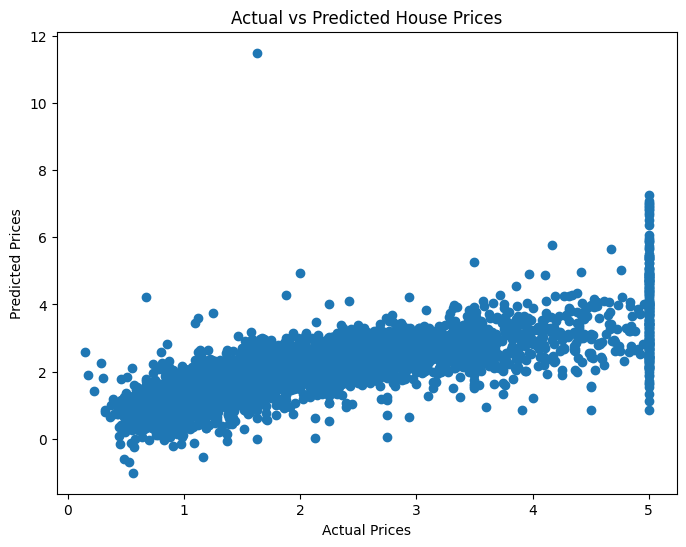

In [8]:
# -------------------------------
# Step 11: Plot Actual vs Predicted Prices
# -------------------------------
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")

plt.show()